In [1]:
import numpy as np

def generate_fake_light_curve():
    time = np.sort(np.random.random_sample(size=(20))*100)
    mean_mag = np.random.random()*10+10
    mean_error = (mean_mag-9)/10
    mag = np.random.random(20)*(np.random.random()+1)*3+mean_mag+np.random.normal(loc=0,scale=mean_error,size=20)
    error = np.abs(np.random.normal(loc=mean_error,scale=mean_error/10,size=20))
    return time,mag,error


<ErrorbarContainer object of 3 artists>

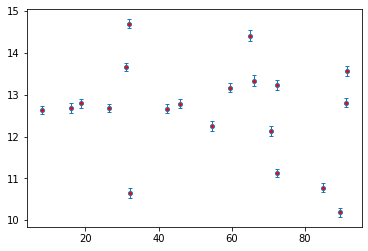

In [2]:
import matplotlib.pyplot as plt
time,mag,error = generate_fake_light_curve()
plt.errorbar(time,mag,error, fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)

In [3]:
lc_list = []
for i in range(0,10000):
    lc_list.append(generate_fake_light_curve())

In [91]:
def reduced_chi_Square(flux,error):
    sigma2 = np.power(error,2)
    mean_flux = np.sum(np.divide(flux,sigma2))/np.sum(np.divide(1,sigma2))
    N = len(flux)
    return np.sum(np.divide(np.power(flux-mean_flux,2),sigma2))/N -1 


In [11]:
def weighted_sigma(mag,error):
    sigma2 = np.power(error,2)
    weights = np.divide(1,sigma2)
    mean_mag = np.sum(np.divide(mag,sigma2))/np.sum(np.divide(1,sigma2))
    return np.sqrt(np.sum(weights)*np.sum(np.multiply(weights,np.power(mag-mean_mag,2)))/(np.sum(weights)**2-np.sum(np.power(weights,2))))


In [119]:
from scipy import stats
def Median_absolute_deviation(mag):
    return stats.median_abs_deviation(mag)

In [121]:
def Interquartile_range(mag):
    return stats.iqr(mag)

In [9]:
def Robust_median_statistic(mag,error):
    N = len(mag)
    median_mag = np.median(mag)
    return np.sum(np.divide(np.abs(mag-median_mag),error))/(N-1)

In [6]:
def Normalized_excess_variance(mag,error):
    """
    Calculate the normalized excess variance of a light curve.
    """
    sigma2 = np.power(error,2)
    mean_mag = np.sum(np.divide(mag,sigma2))/np.sum(np.divide(1,sigma2))
    return np.sum(np.power(mag-mean_mag,2)-sigma2)/(len(mag)*mean_mag**2)   
    
    

In [19]:
def Peak_to_peak_variability(mag,error):
    return (np.max(mag-error)-np.min(mag+error))/(np.max(mag-error)+np.min(mag+error))

In [4]:
def Lag_1_autocorrelation(mag,error):
    sigma2 = np.power(error,2)
    mean_mag = np.sum(np.divide(mag,sigma2))/np.sum(np.divide(1,sigma2))
    mag_shifted = mag - mean_mag    
    lag_1_autocorr = np.sum(np.multiply(mag_shifted[1:],mag_shifted[:-1]))/np.sum(mag_shifted**2)  
    return lag_1_autocorr    

In [ ]:
# def Welch_Stetson_variability_index_I()

In [7]:
def Stetson_J(mag,error):
    """
    Stetson J index
    """    
    sigma2 = np.power(error,2)
    mean_mag = np.sum(np.divide(mag,sigma2))/np.sum(np.divide(1,sigma2))
    N = len(mag)
    delta = np.divide(np.sqrt(N/(N-1))*(mag-mean_mag),error)
    product = np.multiply(delta[1:],delta[:-1])
    return np.sum(np.multiply(np.sign(product),np.sqrt(np.abs(product))))

In [14]:
def Stetson_K(mag,error):
    sigma2 = np.power(error,2)
    mean_mag = np.sum(np.divide(mag,sigma2))/np.sum(np.divide(1,sigma2))
    N = len(mag)
    delta = np.divide(np.sqrt(N/(N-1))*(mag-mean_mag),error)
    denominator = np.sqrt(np.sum(np.power(delta,2)*(1/N)))
    return (1/N)*np.sum(np.abs(delta))/denominator

In [25]:
def yita(mag,error):
    sigma2 = np.power(error,2)
    mean_mag = np.sum(np.divide(mag,sigma2))/np.sum(np.divide(1,sigma2))
    return np.sum(np.power(mag[1:]-mag[:-1],2))/np.sum(np.power(mag-mean_mag,2))

In [26]:
para_list = []
for lc in lc_list:
    print(yita(lc[1],lc[2]))
    para_list.append(yita(lc[1],lc[2]))

2.850050413947518
1.7867635087286782
1.6645789181918016
2.228243373855114
1.4945081438910985
2.4235945954916405
2.698906902881803
1.3636195918488423
1.0637918655492198
2.4270758574983238
1.3353399479128247
2.6785601130065366
2.6104487081185117
2.3238190170701367
2.001804237143554
2.035414782220466
1.6366327242835823
2.386982285373085
0.8620911117633573
2.4620904899211955
1.4283596409408397
1.9768102294262369
2.034011613318928
1.262310029486238
1.372985750982928
1.0856066119186154
2.0419174542469984
2.7498511539667074
1.615809931409805
2.5183188469743474
2.6424065687224294
2.49674701954799
1.8201066216215924
1.8324421759729672
2.230153556249521
1.7510462069308899
1.5529272234451181
1.9728074742954462
2.700052398376033
2.533170784112747
1.9996351841652067
2.216429847050353
1.7754030107795788
2.202277148481669
1.321974092374785
1.4564363242641074
2.3604585584891598
2.0196903899412804
1.8044939919144056
2.0257558391009423
1.2840099825707665
2.796455921307194
1.4308105886473363
1.8312580092

(array([   9.,   88.,  535., 1534., 2546., 2729., 1736.,  687.,  129.,
           7.]),
 array([0.3955905 , 0.70956703, 1.02354356, 1.3375201 , 1.65149663,
        1.96547316, 2.2794497 , 2.59342623, 2.90740276, 3.2213793 ,
        3.53535583]),
 <BarContainer object of 10 artists>)

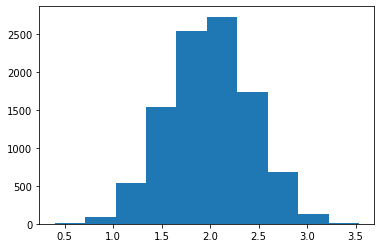

In [27]:
import matplotlib.pyplot as plt

plt.hist(np.array(para_list))

<ErrorbarContainer object of 3 artists>

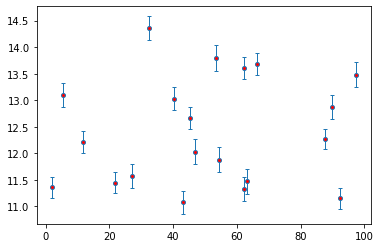

In [13]:
plt.errorbar(lc_list[6][0],lc_list[6][1],lc_list[6][2], fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)